# Decision Tree Project - Breast Cancer Dataset

The goal of this notebook is to use Scikit-Learn's and from scratch decision tree models to implement a complete machine learning project using **Scikit-Learn's breast cancer dataset**.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix, classification_report, roc_curve, auc

import matplotlib.pyplot as plt

import joblib

from decision_tree import DecisionTreeClassifier as DecisionTreeClassifierScratch

## 2. Load dataset

In [2]:
df = pd.DataFrame(load_breast_cancer().data, columns=load_breast_cancer().feature_names)
df['target'] = load_breast_cancer().target # binary classification: malignant or benign

In [3]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
print("Shape:\n", df.shape)
print("Head:\n", df.head())
print("Description:\n", df.describe())
print("Null Values:\n", df.isnull().sum())

Shape:
 (569, 31)
Head:
    mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  wor

Clean dataset with **no missing values, 30 numerical features and 569 samples**.

We also notice that for the target, the mean is 0.627 meaning that ~63% of samples are class 1 (benign) and ~37% of them Class 0 (malignant). 

The **dataset is slightly imbalanced**. Not critically so, but it means that accuracy alone isn’t a sufficient metric. A model that always predicts 1 would already have 63% accuracy without learning anything.

That’s why we'll also look at precision, recall, and F1 score in the evaluation, especially for class 0 (malignant), where a false negative is clinically dangerous.

## 3. Train and test datasets

In [5]:
# Prepare the data: target variable and features
X = df.drop("target", axis=1).values # features
y = df["target"].values # target

In [6]:
# Split datasets into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. Train with Decision Tree Classifier model from scratch

In [8]:
# Train and fit the scratch Decision Tree model
model_scratch = DecisionTreeClassifierScratch(max_depth=5, min_samples_split=2)
model_scratch.fit(X_train_scaled, y_train)

In [9]:
# Evaluate the scratch model
# Train set evaluation
predictions_scratch_train = model_scratch.predict(X_train_scaled)
accuracy_scratch_train = accuracy_score(y_train, predictions_scratch_train)
f1_score_scratch_train = f1_score(y_train, predictions_scratch_train)
recall_scratch_train = recall_score(y_train, predictions_scratch_train)

print("Scratch Decision Tree - Train Accuracy:", accuracy_scratch_train)
print("Scratch Decision Tree - Train F1 Score:", f1_score_scratch_train)
print("Scratch Decision Tree - Train Recall:", recall_scratch_train)

Scratch Decision Tree - Train Accuracy: 0.9956043956043956
Scratch Decision Tree - Train F1 Score: 0.9965156794425087
Scratch Decision Tree - Train Recall: 1.0


In [10]:
# Test set evaluation
predictions_scratch_test = model_scratch.predict(X_test_scaled)
accuracy_scratch_test = accuracy_score(y_test, predictions_scratch_test)
f1_score_scratch_test = f1_score(y_test, predictions_scratch_test)
recall_scratch_test = recall_score(y_test, predictions_scratch_test)

print("Scratch Decision Tree - Test Accuracy:", accuracy_scratch_test)
print("Scratch Decision Tree - Test F1 Score:", f1_score_scratch_test)
print("Scratch Decision Tree - Test Recall:", recall_scratch_test)

Scratch Decision Tree - Test Accuracy: 0.9298245614035088
Scratch Decision Tree - Test F1 Score: 0.9428571428571428
Scratch Decision Tree - Test Recall: 0.9295774647887324


In [11]:
# Print confusion matrix and classification report for test set
conf_matrix = confusion_matrix(y_test, predictions_scratch_test)
print("Confusion Matrix:\n", conf_matrix)

class_report = classification_report(y_test, predictions_scratch_test)
print("Classification Report:\n", class_report)

Confusion Matrix:
 [[40  3]
 [ 5 66]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.93      0.91        43
           1       0.96      0.93      0.94        71

    accuracy                           0.93       114
   macro avg       0.92      0.93      0.93       114
weighted avg       0.93      0.93      0.93       114



## 5. Train with Decision Tree Classifier from Scikit-Learn

In [12]:
# Train scikit-learn's Decision Tree model
model_sklearn = DecisionTreeClassifier(max_depth=5, min_samples_split=2)
model_sklearn.fit(X_train_scaled, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [13]:
# Evaluate scikit-learn model
# Train set evaluation
predictions_sklearn_train = model_sklearn.predict(X_train_scaled)
accuracy_sklearn_train = accuracy_score(y_train, predictions_sklearn_train)
f1_score_sklearn_train = f1_score(y_train, predictions_sklearn_train)
recall_sklearn_train = recall_score(y_train, predictions_sklearn_train)

print("Scikit-learn Decision Tree - Train Accuracy:", accuracy_sklearn_train)
print("Scikit-learn Decision Tree - Train F1 Score:", f1_score_sklearn_train)
print("Scikit-learn Decision Tree - Train Recall:", recall_sklearn_train)

Scikit-learn Decision Tree - Train Accuracy: 0.9956043956043956
Scikit-learn Decision Tree - Train F1 Score: 0.9965156794425087
Scikit-learn Decision Tree - Train Recall: 1.0


In [14]:
# Test set evaluation
predictions_sklearn_test = model_sklearn.predict(X_test_scaled)
accuracy_sklearn_test = accuracy_score(y_test, predictions_sklearn_test)
f1_score_sklearn_test = f1_score(y_test, predictions_sklearn_test)
recall_sklearn_test = recall_score(y_test, predictions_sklearn_test)

print("Scikit-learn Decision Tree - Test Accuracy:", accuracy_sklearn_test)
print("Scikit-learn Decision Tree - Test F1 Score:", f1_score_sklearn_test)
print("Scikit-learn Decision Tree - Test Recall:", recall_sklearn_test)

Scikit-learn Decision Tree - Test Accuracy: 0.9385964912280702
Scikit-learn Decision Tree - Test F1 Score: 0.950354609929078
Scikit-learn Decision Tree - Test Recall: 0.9436619718309859


In [15]:
# Print confusion matrix and classification report for test set
conf_matrix_sklearn = confusion_matrix(y_test, predictions_sklearn_test)
print("Confusion Matrix:\n", conf_matrix_sklearn)

class_report_sklearn = classification_report(y_test, predictions_sklearn_test)
print("Classification Report:\n", class_report_sklearn)

Confusion Matrix:
 [[40  3]
 [ 4 67]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.93      0.92        43
           1       0.96      0.94      0.95        71

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



In medical contexts such as breast cancer, the most important metric is **recall for class 0 (malignant)**. 

In this context: 

**Class 0 = malignant**: a false negative means telling a patient who has cancer that they are “benign” is dangerous.

Therefore, recall for class 0 matters most, we want to **minimize false negatives**.

We observe the following recall rates for Class 0: 
- sklearn: Class 0 recall = 0.91
- scratch: Class 0 recall = 0.93 (better)

The scratch model is therefore the best when considering the Class 0 recall metric. 

## 6. Dataset and decision boundary visualization

In [16]:
# Compute the probabilities for the test set using the scratch model
y_proba_scratch_test = model_scratch.predict_proba(X_test_scaled)

In [17]:
# Compute the probabilities for the test set using scikit-learn model
y_proba_sklearn_test = model_sklearn.predict_proba(X_test_scaled)[:, 1]

In [18]:
# ROC curves
# Scratch model
fpr_scratch, tpr_scratch, _ = roc_curve(y_test, y_proba_scratch_test)
auc_scratch = auc(fpr_scratch, tpr_scratch)

# Sklearn model
fpr_sklearn, tpr_sklearn, _ = roc_curve(y_test, y_proba_sklearn_test)
auc_sklearn = auc(fpr_sklearn, tpr_sklearn)

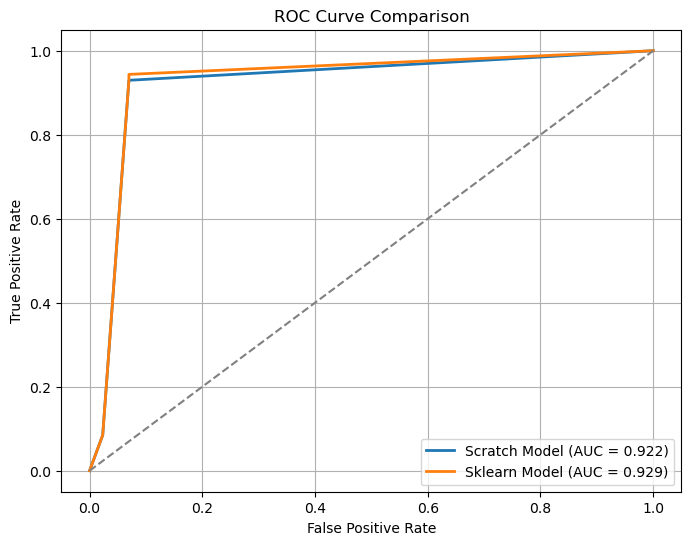

In [19]:
# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_scratch, tpr_scratch, label=f"Scratch Model (AUC = {auc_scratch:.3f})", linewidth=2)
plt.plot(fpr_sklearn, tpr_sklearn, label=f"Sklearn Model (AUC = {auc_sklearn:.3f})", linewidth=2)

# Add a diagonal line for reference (random classifier)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

The two curves are nearly identical with an AUC of 0.922 for the scratch implementation vs. 0.929 for the sklearn implementation. 

A difference of 0.007, which is negligible.

This is a very good validation of our implementation: the same overall behavior across the entire range of thresholds, not just at the 0.5 threshold.

## 7. Save models

In [20]:
# Save both models
joblib.dump(model_scratch, "models/decision_tree_classifier_scratch.pkl")
joblib.dump(model_sklearn, "models/decision_tree_classifier_sklearn.pkl")

['models/decision_tree_classifier_sklearn.pkl']

In [21]:
# Verify that the models are saved correctly
loaded_scratch_model = joblib.load("models/decision_tree_classifier_scratch.pkl")
loaded_sklearn_model = joblib.load("models/decision_tree_classifier_sklearn.pkl")

In [22]:
# Predict the test set with the loaded models
predictions_loaded_scratch = loaded_scratch_model.predict(X_test_scaled)
predictions_loaded_sklearn = loaded_sklearn_model.predict(X_test_scaled)

In [23]:
# Compare predictions from loaded models with original predictions
np.allclose(predictions_scratch_test, predictions_loaded_scratch), np.allclose(predictions_sklearn_test, predictions_loaded_sklearn)

(True, True)

In [24]:
# Save the scalar to perform during predictions the exact transformation
joblib.dump(scaler, "models/scaler.pkl")

['models/scaler.pkl']